# Clustering

## *Workshop 10*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W10.%20Clustering.ipynb)

Last week every observation came with a label (did this passenger survive?). This week there are **no labels**. We want to find groups we didn't know to look for: which London neighbourhoods are alike, which satellite detections belong to the same oil platform. That is **unsupervised learning**, and the most common version of it is **clustering**.

The workshop follows the lecture:

1. **Finding oil rigs from space**: a first look at the problem
2. **K-means**: building a mini geodemographic classification of London's 624 wards
3. **Hierarchical clustering**: London's 32 boroughs as a family tree
4. **DBSCAN**: air-quality sensors in California, then back to the oil rigs
5. **Using clusters responsibly**: clustering always finds clusters

### Aims

- Build a feature matrix, standardise it, and explain why standardising matters
- Run k-means, choose k with elbow and silhouette plots, and profile (and name) the clusters
- Read a dendrogram and cut it into clusters
- Run DBSCAN with a radius that has a real-world meaning (km, metres), and explain when it beats k-means
- Critically assess a clustering: is the structure real, and are the labels fair?

**Data.** Offshore infrastructure locations: [Global Fishing Watch](https://globalfishingwatch.org/datasets-and-code/offshore-infrastructure/) (CC BY-NC 4.0). London ward populations and areas: ONS / London Datastore (the same file as the lecture). California air quality: US EPA (Week 3).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.datasets import make_blobs, make_moons
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style="whitegrid", context="notebook")
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
sns.set_palette(PAL)
R_EARTH_KM = 6371

# 1. Finding oil rigs from space

Global Fishing Watch maps offshore oil platforms and wind turbines worldwide from **Sentinel-1 radar** and **Sentinel-2 optical** imagery. Every image produces thousands of detections of bright objects at sea. Most are ships, which we can remove because they broadcast their position (AIS). What's left is a noisy mix of fixed structures, unmatched vessels and artefacts.

The key insight: **ships move, platforms don't**. A platform is detected at the same spot, pass after pass. So we look for places where detections **pile up**. That's a clustering problem.

We'll work in the **southern North Sea** (between East Anglia, the Netherlands and Belgium): old gas platforms plus some of the world's biggest wind farms.

First, the answer key: GFW's published list of structures in this box.

In [2]:
BASE = "https://storage.googleapis.com/qm2/2627/w10/"
structures = pd.read_csv(BASE + "structures.csv", parse_dates=["first_seen", "last_seen"])
print(structures.shape)
structures.head()

(2371, 8)


,structure_id,lat,lon,label,first_seen,last_seen,n_months,eez
0,2709,51.666971,2.745049,wind,2019-11-01,2022-01-01,27,Belgium
1,2757,53.986850,1.733612,wind,2020-10-01,2022-01-01,16,United Kingdom
2,2784,51.592786,2.980317,wind,2017-09-01,2022-01-01,53,Belgium
3,2794,51.695871,3.049368,wind,2020-04-01,2022-01-01,22,Netherlands
4,3296,53.893745,1.784230,wind,2018-12-01,2022-01-01,38,United Kingdom


In [3]:
structures["label"].value_counts()

label
wind       2105
oil         225
unknown      41
Name: count, dtype: int64

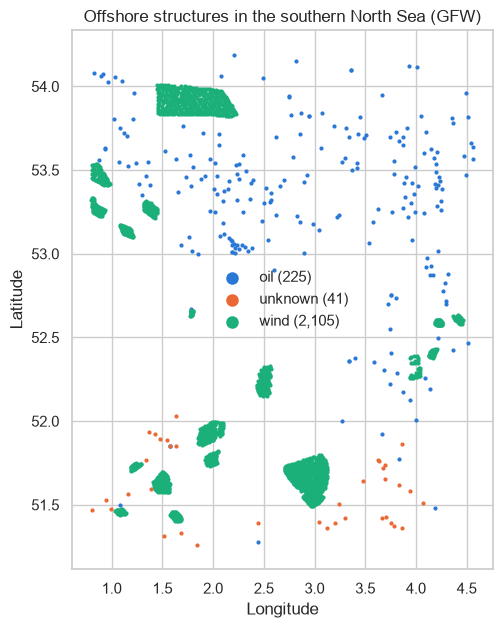

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
for i, (lab, g) in enumerate(structures.groupby("label")):
    ax.scatter(g.lon, g.lat, s=4, color=PAL[i], label=f"{lab} ({len(g):,})")
ax.set(xlabel="Longitude", ylabel="Latitude", title="Offshore structures in the southern North Sea (GFW)")
ax.set_aspect(1 / np.cos(np.radians(52.7)))   # so a km east looks as long as a km north
ax.legend(markerscale=4, frameon=False)
plt.show()

The lines and grids are wind farms; the scattered points further north are mostly gas platforms.

**Where do these locations come from?** GFW's public table holds one cleaned location per structure. It doesn't include the raw satellite detections that went into finding them. So, to practise the method, we've **simulated** those raw detections (script: `notebooks/data_prep/w10_offshore.py`):

- each structure present in a 6-month window is detected on about 15 of ~30 radar passes, each time a few tens of metres off (radar pixels are 10 m and positions are noisy)
- 15,000 detections of **unmatched vessels** are scattered at random across the box
- 40 **anchored vessels** swing around a fixed spot, producing loose pile-ups (these are the tricky ones)

The structure locations are real; the detections are made up but realistic in spirit. There are two windows, the first half of 2019 and the first half of 2021.

window
2021H1    48336
2019H1    42417
Name: count, dtype: int64


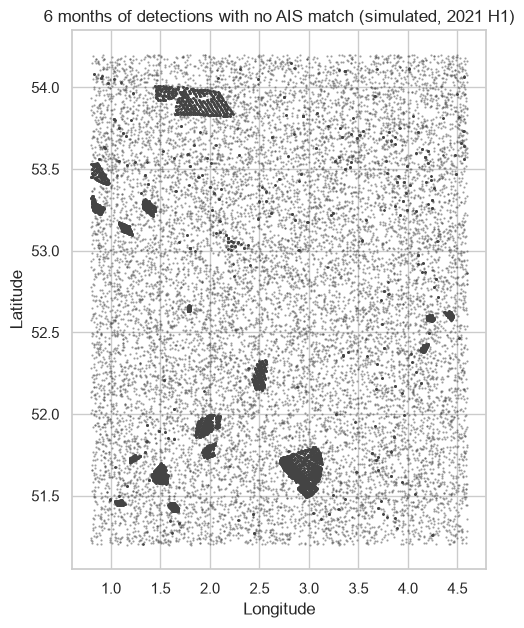

In [5]:
det = pd.read_csv(BASE + "detections_sim.csv")
print(det["window"].value_counts())
det21 = det[det["window"] == "2021H1"].copy()

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(det21.lon, det21.lat, s=0.3, color="#444444", alpha=0.5)
ax.set(xlabel="Longitude", ylabel="Latitude", title="6 months of detections with no AIS match (simulated, 2021 H1)")
ax.set_aspect(1 / np.cos(np.radians(52.7)))
plt.show()

At this scale the structures and the noise blur together. Zoom into a small patch, about 7 km across, off the Belgian coast:

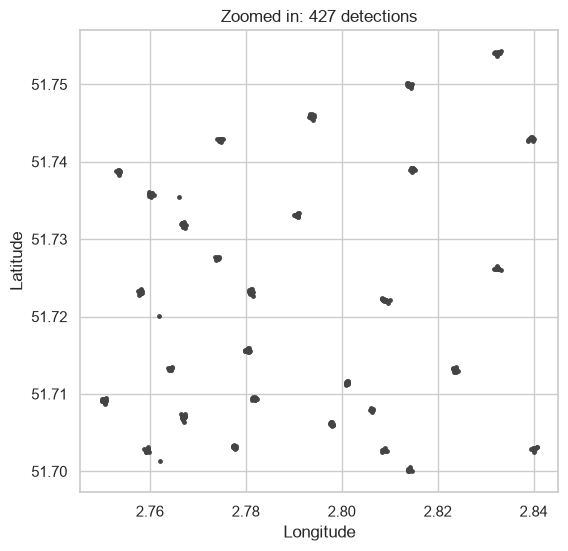

In [6]:
def zoom(df, lon=(2.75, 2.85), lat=(51.70, 51.76)):
    return df[df.lon.between(*lon) & df.lat.between(*lat)]

z = zoom(det21)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z.lon, z.lat, s=6, color="#444444")
ax.set(xlabel="Longitude", ylabel="Latitude", title=f"Zoomed in: {len(z)} detections")
ax.set_aspect(1 / np.cos(np.radians(51.7)))
plt.show()

### Exercise 1.1

Look at the zoomed plot. Roughly **how many structures** do you think are in this patch? How did you decide which points belong together, and which are noise? Write down your answer; we'll get the algorithm to do the same in Section 4.

*Your answer here.*

Keep your answer in mind: what you just did by eye used **features** (the position of each point), a **distance** (how close points are), and a **scale** (what counts as "close"). Every clustering method needs all three.

# 2. K-means

## 2.1 How k-means works

K-means tries to make each cluster as **tight** as possible: it minimises the total squared distance from each point to its cluster's centre (the *centroid*).

1. Drop k centroids at random
2. Assign each point to its nearest centroid
3. Move each centroid to the mean of its points
4. Repeat 2–3 until nothing changes

Let's watch it work on data where the answer is obvious (the lecture's "how many groups do you see?" example).

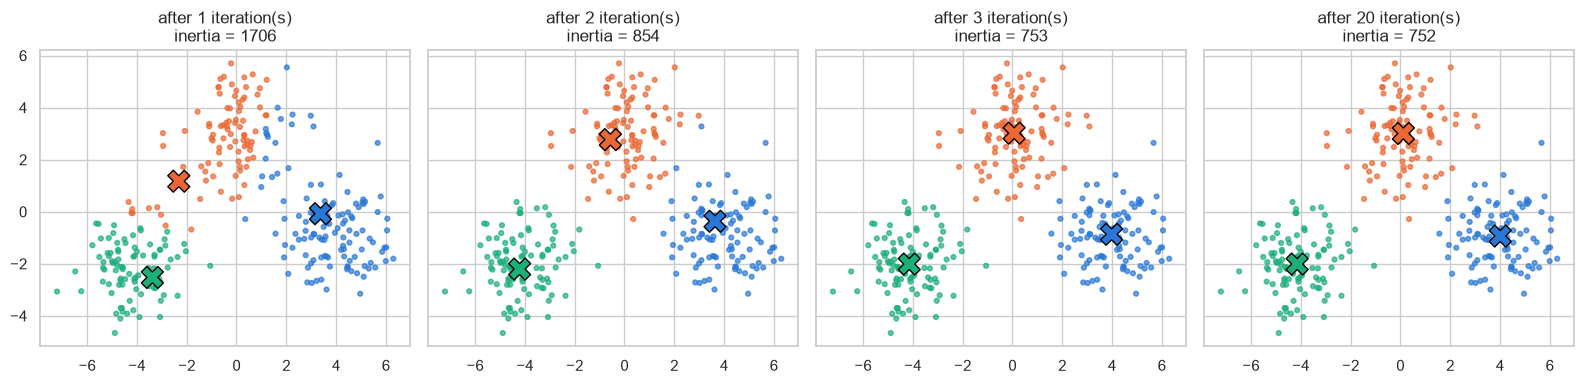

In [7]:
Xb, _ = make_blobs(n_samples=300, centers=[(-4, -2), (0, 3), (4, -1)], cluster_std=1.1, random_state=3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, n_iter in zip(axes, [1, 2, 3, 20]):
    # init='random' + one start + a few iterations lets us watch the algorithm mid-way
    km = KMeans(n_clusters=3, init="random", n_init=1, max_iter=n_iter, random_state=4).fit(Xb)
    ax.scatter(Xb[:, 0], Xb[:, 1], s=12, c=[PAL[l] for l in km.labels_], alpha=0.7)
    ax.scatter(*km.cluster_centers_.T, s=250, marker="X", c=PAL[:3], edgecolors="black")
    ax.set_title(f"after {n_iter} iteration(s)\ninertia = {km.inertia_:.0f}")
plt.tight_layout(); plt.show()

**Inertia** is the thing k-means minimises: the total squared distance from points to their centroids. It falls as the centroids settle.

The fine print (from the lecture):

- **You must choose k** before you start
- **Random starts** can land in a bad solution, so scikit-learn runs it `n_init` times and keeps the best
- It assumes clusters are **round and similar in size**
- **Every point** is assigned to a cluster, even outliers

## 2.2 Case study: London geodemographics

**Geodemographics** classifies neighbourhoods by who lives there. The UK's Output Area Classification, developed at UCL with the ONS, uses k-means on census variables to group every small area in the country. It is used in retail, public health and policy.

We'll build a mini version for London's **624 wards**. The file has the population of each ward in 5-year age bands, plus its area in hectares.

In [8]:
wards = pd.read_csv("https://qm2.s3.eu-west-2.amazonaws.com/wk9/borough_density.csv")
age_cols = ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49",
            "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80-84", "85-89", "90plus"]
print(wards.shape)
wards[["NAME", "Local Authority", "All Ages", "HECTARES"] + age_cols[:6]].head()

(624, 41)


,NAME,Local Authority,All Ages,HECTARES,0-4,5-9,10-14,15-19,20-24,25-29
0,Chessington South Ward,Kingston upon Thames,10246.0,755.173,761,616,630,621,590,695
1,Tolworth and Hook Rise Ward,Kingston upon Thames,9848.0,259.464,713,573,579,638,629,724
2,Berrylands Ward,Kingston upon Thames,9475.0,145.390,674,461,396,411,773,820
3,Alexandra Ward,Kingston upon Thames,9263.0,268.506,611,575,632,549,588,565
4,Beverley Ward,Kingston upon Thames,10123.0,187.821,740,628,609,613,634,707


**Features.** We describe each ward with 7 numbers: the share of residents in 6 age bands, and population density.

In [9]:
bands = {"Children (0-14)":      ["0-4", "5-9", "10-14"],
         "Young adults (15-24)": ["15-19", "20-24"],
         "25-34":                ["25-29", "30-34"],
         "35-49":                ["35-39", "40-44", "45-49"],
         "50-64":                ["50-54", "55-59", "60-64"],
         "65+":                  ["65-69", "70-74", "75-79", "80-84", "85-89", "90plus"]}

X = pd.DataFrame({band: wards[cols].sum(axis=1) / wards["All Ages"] for band, cols in bands.items()})
X["Density (people/ha)"] = wards["All Ages"] / wards["HECTARES"]
X.index = wards["NAME"]
X.describe().round(3)

,Children (0-14),Young adults (15-24),25-34,35-49,50-64,65+,Density (people/ha)
count,624.000,624.000,624.000,624.000,624.000,624.000,624.000
mean,0.186,0.132,0.197,0.225,0.146,0.114,80.319
std,0.035,0.031,0.063,0.020,0.030,0.039,47.224
min,0.070,0.067,0.071,0.169,0.074,0.035,1.761
25%,0.166,0.114,0.147,0.212,0.123,0.083,45.298
50%,0.184,0.130,0.191,0.224,0.142,0.107,68.600
75%,0.206,0.145,0.240,0.237,0.168,0.138,107.920
max,0.309,0.330,0.390,0.289,0.236,0.237,265.061


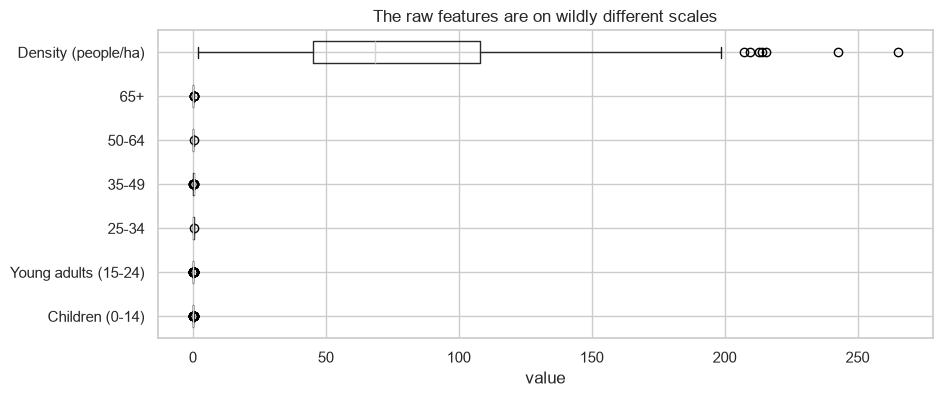

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
X.boxplot(ax=ax, vert=False)
ax.set(title="The raw features are on wildly different scales", xlabel="value")
plt.show()

## 2.3 Spot the problem: forgetting to scale

A colleague runs k-means straight on this table and reports five neighbourhood types. Here are their results.

In [11]:
km_raw = KMeans(n_clusters=5, n_init=20, random_state=0).fit(X)
X.groupby(km_raw.labels_).mean().round(3).assign(n_wards=pd.Series(km_raw.labels_).value_counts())

,Children (0-14),Young adults (15-24),25-34,35-49,50-64,65+,Density (people/ha),n_wards
0,0.176,0.140,0.250,0.226,0.124,0.084,124.914,89
1,0.193,0.129,0.171,0.226,0.156,0.124,54.912,197
2,0.168,0.143,0.261,0.223,0.120,0.084,172.690,74
3,0.187,0.125,0.139,0.219,0.175,0.155,26.189,124
4,0.189,0.132,0.219,0.228,0.135,0.097,86.842,140


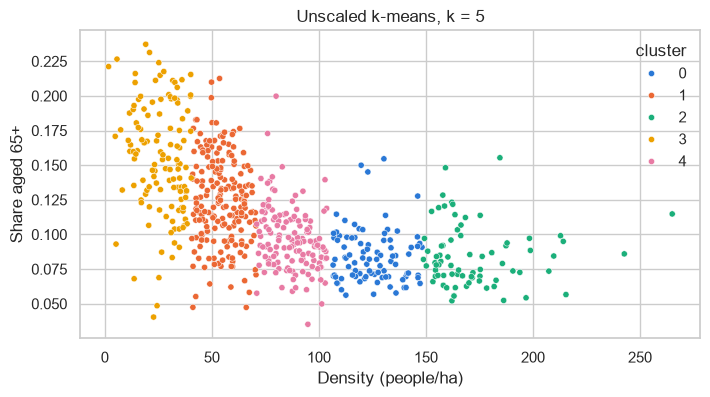

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=X["Density (people/ha)"], y=X["65+"], hue=km_raw.labels_, palette=PAL[:5], s=20, ax=ax)
ax.set(title="Unscaled k-means, k = 5", ylabel="Share aged 65+")
ax.legend(title="cluster", frameon=False)
plt.show()

### Exercise 2.1

Look at the table and the plot. **What are these five "neighbourhood types" really based on?** Why did this happen? (Hint: k-means uses Euclidean distance, $d(a,b) = \sqrt{(a_1-b_1)^2 + (a_2-b_2)^2 + \dots}$. How big is a typical difference in density compared with a typical difference in the share aged 65+?)

*Your answer here.*

**The fix** has two parts:

1. Density is very skewed (a few wards are extremely dense), so take its **log**.
2. **Standardise** every feature to mean 0 and standard deviation 1, so each counts equally in the distance.

In [13]:
X["Density (people/ha)"] = np.log(X["Density (people/ha)"])
X = X.rename(columns={"Density (people/ha)": "Log density"})

Z = StandardScaler().fit_transform(X)
Z = pd.DataFrame(Z, columns=X.columns, index=X.index)
Z.describe().round(2).loc[["mean", "std"]]

,Children (0-14),Young adults (15-24),25-34,35-49,50-64,65+,Log density
mean,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 2.4 Choosing k

There's no right answer to check against, so we use two diagnostics:

- **Elbow:** plot inertia against k and look for where adding clusters stops helping much
- **Silhouette:** for each point, how much closer it is to its own cluster than to the next nearest one, averaged (−1 to 1; higher is better)

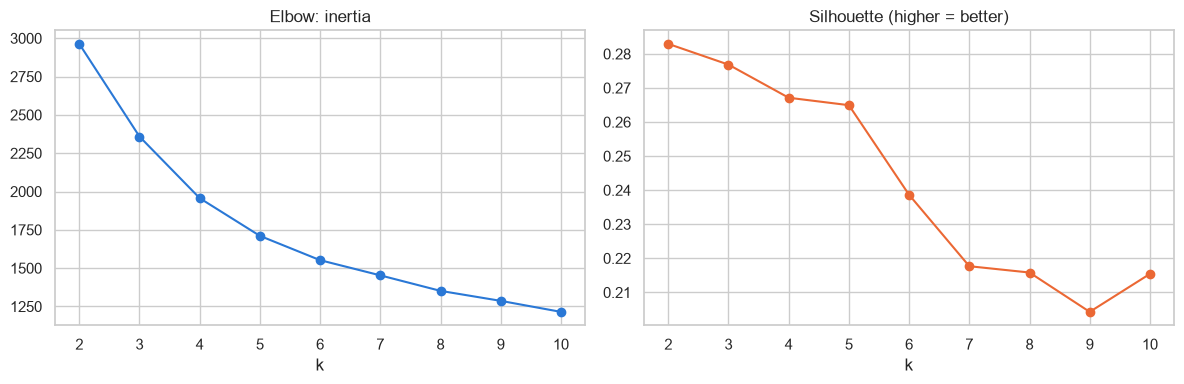

,2,3,4,5,6,7,8,9,10
silhouette,0.283,0.277,0.267,0.265,0.239,0.218,0.216,0.204,0.215


In [14]:
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(Z)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Z, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, "o-", color=PAL[0]); axes[0].set(title="Elbow: inertia", xlabel="k")
axes[1].plot(list(ks), sil, "o-", color=PAL[1]); axes[1].set(title="Silhouette (higher = better)", xlabel="k")
plt.tight_layout(); plt.show()
pd.Series(sil, index=ks, name="silhouette").round(3).to_frame().T

### Exercise 2.2

1. Is there a clear elbow?
2. Silhouette is highest at k = 2. Why might we still prefer k = 5? What would a two-cluster London probably look like?

*Your answer here.*

Choosing k is a **judgement call**, not a calculation. Like the lecture, we'll go with **k = 5**.

In [15]:
km5 = KMeans(n_clusters=5, n_init=50, random_state=0).fit(Z)
wards["cluster"] = km5.labels_
print("silhouette:", round(silhouette_score(Z, km5.labels_), 3))
wards["cluster"].value_counts().sort_index()

silhouette: 0.265


cluster
0    164
1    131
2    111
3     60
4    158
Name: count, dtype: int64

Each ward's boundary is stored as text (WKT) in the `geometry` column, so we can map the clusters.

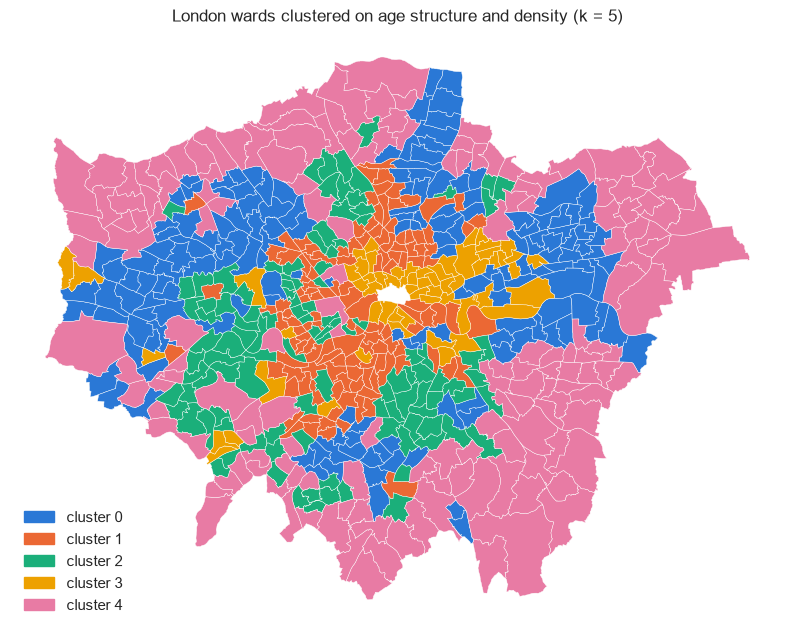

In [16]:
gwards = gpd.GeoDataFrame(wards, geometry=gpd.GeoSeries.from_wkt(wards["geometry"]), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 8))
for k in range(5):
    gwards[gwards.cluster == k].plot(ax=ax, color=PAL[k], edgecolor="white", linewidth=0.3, label=f"cluster {k}")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=PAL[k]) for k in range(5)],
          labels=[f"cluster {k}" for k in range(5)], loc="lower left", frameon=False)
ax.set_axis_off(); ax.set_title("London wards clustered on age structure and density (k = 5)")
plt.show()

## 2.5 What makes each cluster different?

The algorithm outputs numbers 0–4. To interpret them we **profile** each cluster: compare its average features with the London average. The standardised means are handy here: +1 means "one standard deviation above the typical ward".

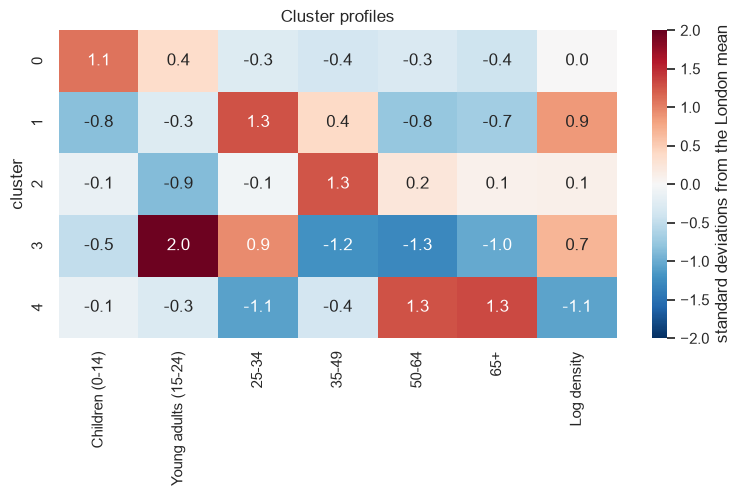

In [17]:
profile = Z.groupby(wards["cluster"].values).mean()

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-2, vmax=2, ax=ax,
            cbar_kws={"label": "standard deviations from the London mean"})
ax.set(ylabel="cluster", title="Cluster profiles")
plt.show()

In [18]:
# Back in real units: the average ward in each cluster
real = X.groupby(wards["cluster"].values).mean()
real["People per ha"] = np.exp(real.pop("Log density"))
real.round(3)

,Children (0-14),Young adults (15-24),25-34,35-49,50-64,65+,People per ha
0,0.224,0.144,0.180,0.217,0.137,0.097,66.467
1,0.156,0.124,0.277,0.233,0.123,0.086,118.633
2,0.181,0.105,0.193,0.250,0.153,0.118,71.476
3,0.168,0.193,0.256,0.200,0.108,0.074,105.019
4,0.180,0.123,0.129,0.217,0.184,0.166,31.832


### Exercise 2.3

1. Give each cluster a short **name** based on its profile (e.g. "older outer suburbs"). Which boroughs are most common in each cluster? (Hint: `wards.groupby("cluster")["Local Authority"].agg(lambda s: s.value_counts().index[:3].tolist())`)
2. Remember: **the names are ours**, not the algorithm's. For which cluster was naming hardest? Which of your names carry a judgement about the people who live there?

In [19]:
# your code here

### Exercise 2.4: random starts

K-means starts from random centroids. Run `KMeans(n_clusters=5, init="random", n_init=1, random_state=s)` for `s` in `range(10)`. For each run, record the inertia and the **adjusted Rand index** against `km5.labels_` (`adjusted_rand_score(km5.labels_, labels)`: 1 = identical groupings, whatever the cluster numbers are called).

Do all runs find the same solution? What does this tell you about why `n_init` exists?

In [20]:
# your code here

# 3. Hierarchical clustering

**Agglomerative** clustering builds a family tree from the bottom up:

1. Start with every observation as its own cluster
2. Merge the two closest clusters
3. Repeat until everything is one cluster

**Linkage** decides what "closest" means for groups: nearest members (`single`), furthest members (`complete`), `average`, or `ward` (the merge that increases within-cluster spread the least; the same idea as k-means' inertia). You don't choose k up front: you cut the tree wherever you like. It's slow for big data, so it suits tens to thousands of observations.

With 624 wards the tree would be unreadable, so let's do London's **32 boroughs** with the same 7 features.

(32, 7)


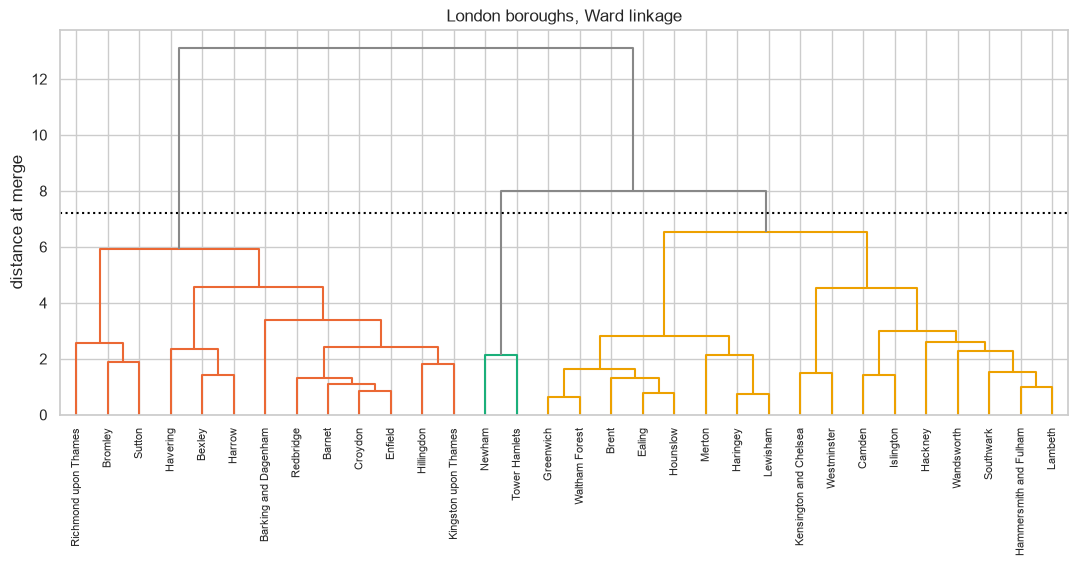

In [21]:
counts = wards.groupby("Local Authority")[age_cols + ["All Ages", "HECTARES"]].sum()
B = pd.DataFrame({band: counts[cols].sum(axis=1) / counts["All Ages"] for band, cols in bands.items()})
B["Log density"] = np.log(counts["All Ages"] / counts["HECTARES"])
ZB = StandardScaler().fit_transform(B)
print(B.shape)

L = linkage(ZB, method="ward")
cut = 0.55 * L[:, 2].max()

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(L, labels=B.index.tolist(), leaf_rotation=90, color_threshold=cut, above_threshold_color="#888888", ax=ax)
ax.axhline(cut, color="black", ls=":")
ax.set(ylabel="distance at merge", title="London boroughs, Ward linkage")
plt.show()

**Reading a dendrogram:** the height of each join shows how different the two merged groups are. Boroughs that join low down are very alike. The dotted line cuts the tree into clusters; every branch it crosses is one cluster.

`fcluster` does the cut for us:

In [22]:
B["tree_cluster"] = fcluster(L, t=3, criterion="maxclust")
B.groupby("tree_cluster").apply(lambda d: ", ".join(d.index))

tree_cluster
1    Barking and Dagenham, Barnet, Bexley, Bromley,...
2                                Newham, Tower Hamlets
3    Brent, Camden, Ealing, Greenwich, Hackney, Ham...
dtype: str

### Exercise 3.1

1. Which two boroughs are the most similar (the lowest join)? Which borough or group joins the rest **last**, and what does its profile look like?
2. Redraw the dendrogram with `method="single"`. How does the tree's shape change? Single linkage is known for "chaining": explain what you see.

In [23]:
# your code here

# 4. DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) has two settings: a radius **ε** (`eps`) and a minimum number of points (`min_samples`).

- **Core** points have at least `min_samples` neighbours within ε; clusters grow outwards from them
- **Border** points are within ε of a core point but don't have enough neighbours themselves
- Everything else is **noise** (label `-1`)

The number of clusters is **discovered**, not chosen.

## 4.1 When k-means fails

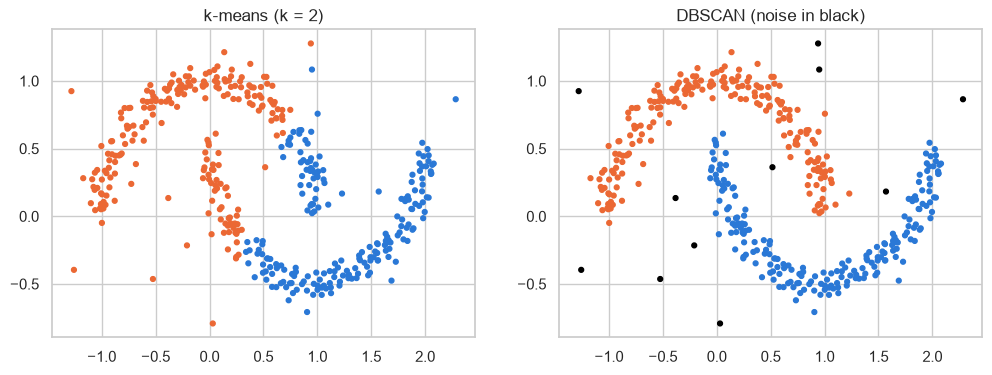

In [24]:
Xm, _ = make_moons(400, noise=0.07, random_state=1)
Xm = np.vstack([Xm, np.random.default_rng(7).uniform([-1.3, -0.8], [2.3, 1.3], (25, 2))])

lab_km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xm)
lab_db = DBSCAN(eps=0.18, min_samples=6).fit_predict(Xm)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(*Xm.T, s=12, c=[PAL[l] for l in lab_km]); axes[0].set_title("k-means (k = 2)")
axes[1].scatter(*Xm.T, s=12, c=["black" if l == -1 else PAL[l] for l in lab_db]); axes[1].set_title("DBSCAN (noise in black)")
plt.show()

k-means draws **straight boundaries** between centroids, so it can't follow curved shapes, and it forces every stray point into a cluster. DBSCAN follows the density of points, and flags the strays as noise.

## 4.2 Air-quality sensors in California

Week 3's air-quality data has daily readings from sensor sites across California. We want to find the groups of sensors that sit together (metropolitan areas) without telling the algorithm where the cities are.

In [25]:
aqi = pd.read_csv("https://qm2.s3.eu-west-2.amazonaws.com/wk3/california_aqi.csv")
sites = (aqi.groupby("Site ID")
            .agg(name=("Site Name", "first"), lat=("latitude", "first"), lon=("longitude", "first"),
                 county=("COUNTY", "first"), aqi=("AQI", "mean"))
            .dropna(subset=["lat", "lon", "aqi"]))
print(len(sites), "sensor sites")
sites.head()

166 sensor sites


,name,lat,lon,county,aqi
Site ID,,,,,
60010007,Livermore,37.687526,-121.784217,Alameda,35.656425
60010009,Oakland,37.743065,-122.169935,Alameda,39.560773
60010011,Oakland West,37.814781,-122.282347,Alameda,34.912429
60010012,Laney College,37.793624,-122.263376,Alameda,35.131868
60010013,Berkeley- Aquatic Park,37.864767,-122.302741,Alameda,41.784916


**Distance on a globe.** Latitude and longitude aren't a flat grid, so we use **haversine** (great-circle) distance. scikit-learn's haversine works in **radians** on a unit sphere, so ε has to be a distance divided by the Earth's radius: 30 km → `30 / 6371`.

A 30 km radius has a real-world meaning: roughly the size of a metropolitan area.

clusters: 9 | noise sites: 87


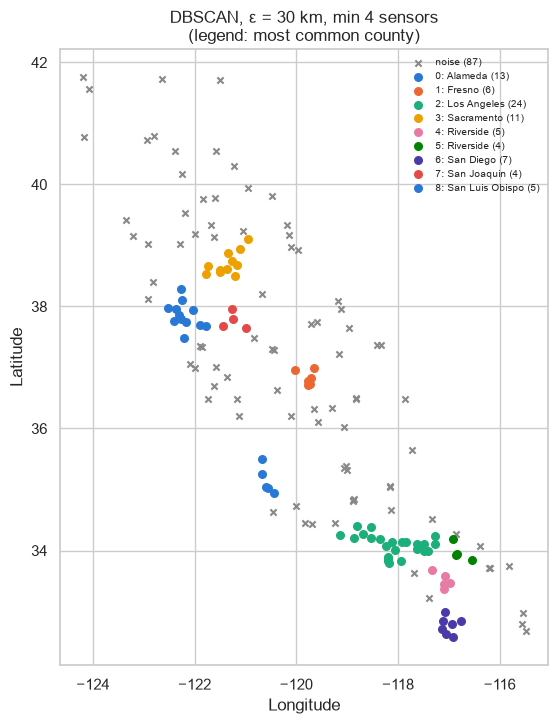

In [26]:
coords = np.radians(sites[["lat", "lon"]])
db = DBSCAN(eps=30 / R_EARTH_KM, min_samples=4, metric="haversine").fit(coords)
sites["dbscan"] = db.labels_
print("clusters:", sites.dbscan.max() + 1, "| noise sites:", (sites.dbscan == -1).sum())

def plot_sites(col, title, ax):
    noise = sites[sites[col] == -1]
    ax.scatter(noise.lon, noise.lat, marker="x", s=20, color="#888888", label=f"noise ({len(noise)})")
    for k in sorted(set(sites[col]) - {-1}):
        s = sites[sites[col] == k]
        ax.scatter(s.lon, s.lat, s=30, color=PAL[k % len(PAL)], label=f"{k}: {s.county.mode()[0]} ({len(s)})")
    ax.set(title=title, xlabel="Longitude", ylabel="Latitude"); ax.set_aspect(1.2)
    ax.legend(fontsize=7, frameon=False, loc="upper right")

fig, ax = plt.subplots(figsize=(7, 8))
plot_sites("dbscan", "DBSCAN, ε = 30 km, min 4 sensors\n(legend: most common county)", ax)
plt.show()

Colours repeat after 8 clusters, so use the legend's cluster numbers and counties.

### Exercise 4.1

1. Run k-means with `k = 9` on the same sites (use `sites[["lat", "lon"]]`; for a small area that's an OK approximation) and plot it with `plot_sites`. What happens to the isolated rural sensors?
2. Try ε = 20 km and ε = 50 km with DBSCAN. How do the number of clusters and the number of noise sites change? Which radius would you defend, and why?

In [27]:
# your code here

## 4.3 Back to the oil rigs

Now the problem from Section 1. GFW's Infrastructure pipeline runs DBSCAN on six months of unmatched detections with a **75 m** radius: tight enough that two turbines a few hundred metres apart stay separate, loose enough to absorb the positional error of each detection.

Why DBSCAN here?

- Nobody knows in advance how many structures there are, and new ones appear every month
- Most detections are **noise**, and DBSCAN is designed to discard it
- The radius has a **physical meaning** (metres) that we can reason about

In [28]:
R_EARTH_M = 6_371_000
db21 = DBSCAN(eps=75 / R_EARTH_M, min_samples=5, metric="haversine")
det21["cluster"] = db21.fit_predict(np.radians(det21[["lat", "lon"]]))

n_clusters = det21.cluster.max() + 1
print(f"{len(det21):,} detections -> {n_clusters:,} clusters, {(det21.cluster == -1).mean():.0%} noise")

48,336 detections -> 2,215 clusters, 32% noise


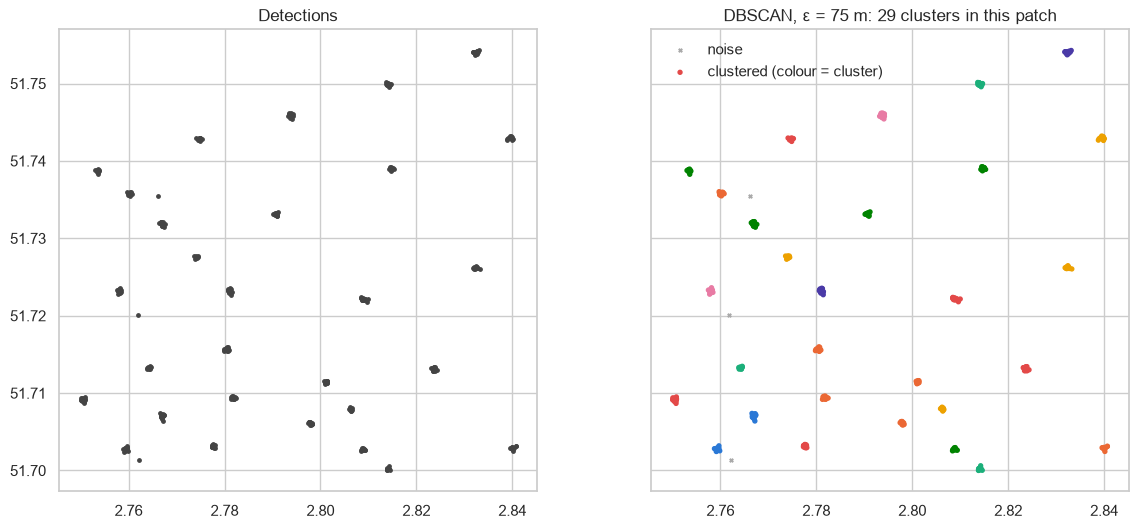

In [29]:
z = zoom(det21)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
axes[0].scatter(z.lon, z.lat, s=6, color="#444444"); axes[0].set_title("Detections")
noise = z[z.cluster == -1]
axes[1].scatter(noise.lon, noise.lat, s=6, marker="x", color="#aaaaaa", label="noise")
clus = z[z.cluster >= 0]
axes[1].scatter(clus.lon, clus.lat, s=8, c=[PAL[c % len(PAL)] for c in clus.cluster], label="clustered (colour = cluster)")
axes[1].set_title(f"DBSCAN, ε = 75 m: {clus.cluster.nunique()} clusters in this patch")
axes[1].legend(frameon=False)
for ax in axes: ax.set_aspect(1 / np.cos(np.radians(51.7)))
plt.show()

How does that compare with your guess in Exercise 1.1?

Each cluster becomes one **candidate structure**, located at the mean of its detections. Because the structure list is real, we can check how well we did: for each true structure, is there a cluster centre within 150 m? And for each cluster, is there a true structure nearby?

In [30]:
from sklearn.neighbors import BallTree

cands = (det21[det21.cluster >= 0].groupby("cluster")
         .agg(lat=("lat", "mean"), lon=("lon", "mean"), n_det=("lat", "size")))
present = structures[(structures.first_seen <= "2021-06-01") & (structures.last_seen >= "2021-01-01")]

def nearest_m(from_df, to_df):
    tree = BallTree(np.radians(to_df[["lat", "lon"]]), metric="haversine")
    dist, _ = tree.query(np.radians(from_df[["lat", "lon"]]), k=1)
    return dist[:, 0] * R_EARTH_M

present = present.assign(dist_to_cluster=nearest_m(present, cands))
cands["dist_to_structure"] = nearest_m(cands, present)

print(f"true structures: {len(present):,}   candidate clusters: {len(cands):,}")
print(f"structures recovered (cluster within 150 m): {(present.dist_to_cluster < 150).mean():.1%}")
print(f"clusters with no structure within 150 m:     {(cands.dist_to_structure > 150).sum()}")

true structures: 2,208   candidate clusters: 2,215
structures recovered (cluster within 150 m): 100.0%
clusters with no structure within 150 m:     10


### Exercise 4.2

1. Every structure was recovered, but a few clusters contain **two** structures. Find them (hint: which pairs of structures in `present` are less than 75 m apart? `BallTree.query(..., k=2)` gives each point's nearest *other* point). Why does DBSCAN merge them, and what would a smaller ε do to the rest of the detections?
2. Look at the clusters with **no** structure nearby (`cands[cands.dist_to_structure > 150]`). How do their number of detections (`n_det`) compare with the real ones? From Section 1, what are they? This is why GFW follows clustering with a **supervised classifier** (oil / wind / noise): clustering first, then classification.

In [31]:
# your code here

### Exercise 4.3: choosing ε

Re-run DBSCAN on `det21` with ε = 10 m, 75 m, 300 m and 1,000 m (keep `min_samples=5`) and record the number of clusters and the share of noise for each. Plot the zoomed square for ε = 1,000 m. What goes wrong at each extreme? (Wind turbines are typically spaced 500–1,000 m apart.)

In [32]:
# your code here

### Optional extension: what's new since 2019?

The lecture's pipeline runs DBSCAN on every 6-month window, then joins the windows together. Cluster the **2019 H1** detections the same way, then find the 2021 candidate structures with **no** 2019 cluster within 150 m. Map them. Can you identify the wind farms that were built between 2019 and 2021? (Compare with `structures.first_seen`.)

In [33]:
# your code here

# 5. Using clusters responsibly

## 5.1 Spot the problem: clustering always finds clusters

A marketing consultancy sends you this slide: *"Our segmentation of 400 customers finds **five distinct segments** (silhouette = 0.40, higher than the London geodemographic classification)."* Here are their data and their clusters.

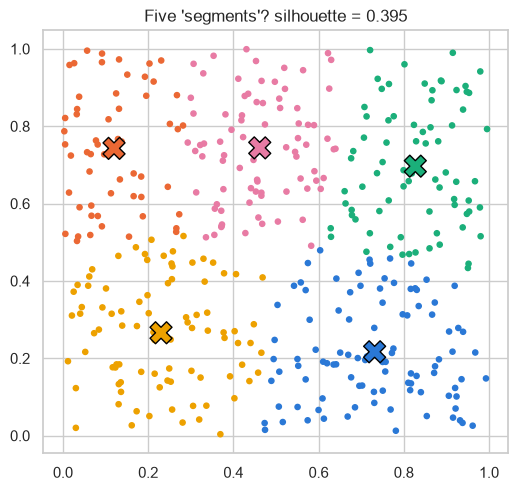

London wards, k = 5: 0.265


In [34]:
rng = np.random.default_rng(7)
customers = rng.uniform(0, 1, size=(400, 2))       # the consultancy's 'data'
seg = KMeans(n_clusters=5, n_init=10, random_state=0).fit(customers)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(*customers.T, s=14, c=[PAL[l] for l in seg.labels_])
ax.scatter(*seg.cluster_centers_.T, s=250, marker="X", c=PAL[:5], edgecolors="black")
ax.set_title(f"Five 'segments'? silhouette = {silhouette_score(customers, seg.labels_):.3f}")
plt.show()
print("London wards, k = 5:", round(silhouette_score(Z, km5.labels_), 3))

The "customers" are **pure random noise**, drawn uniformly. Yet k-means returns five tidy segments, with a silhouette score **higher** than our real London wards. An algorithm will always return groups. Whether they **mean anything** is up to you to show.

### Exercise 5.1

A fairer test: compare the London silhouette with what you'd get from data that has the **same features but no structure**. Shuffle each column of `Z` independently (`Z.apply(lambda c: rng.permutation(c.values))`), which keeps every feature's distribution but destroys the relationships between features. Run k-means with k = 5, and compute the silhouette. Repeat 20 times and plot a histogram, with a line at the real London score.

Is London's structure real? What does this tell you about using a silhouette score on its own?

In [35]:
# your code here

## 5.2 Labels stick to people

Geodemographic labels are used to set insurance premiums, target advertising, allocate policing and public services. Historically, **redlining** in 1930s US cities graded neighbourhoods by "risk", largely by race, and shaped lending for decades.

### Exercise 5.2 (discussion)

1. Your cluster names from Exercise 2.3 describe an **area average**. Pick one ward in your "older" cluster and check the share of residents aged under 35. What would it mean to treat every resident as "old"? (This is the **ecological fallacy**.)
2. Suppose a council used your five clusters to decide where to put new youth services. Who chose the features? Who named the clusters? Who is affected? What feature that we *didn't* include might change the answer?

*Your answer here.*

## 5.3 Which method?

|  | K-means | Hierarchical | DBSCAN |
|---|---|---|---|
| Choose k in advance? | Yes | No (cut the tree) | No (choose ε and min points) |
| Cluster shapes | Round, similar size | Depends on linkage | Any shape |
| Handles noise? | No: every point assigned | No | Yes: labels outliers |
| Speed on big data | Fast | Slow | Fast with spatial indexing |
| Good for | Segmenting areas or customers | Small data; seeing structure | Spatial points; finding hotspots |

### Exercise 5.3

For each task, which method would you use, and what would your features, distance and scale be?

1. Grouping 30,000 GPS pings from fishing vessels into fishing grounds
2. Grouping the 27 EU countries by their economic indicators, to show how they relate
3. Segmenting 2 million supermarket loyalty-card holders by spending

*Your answer here.*

**Beyond points on a map.** Clustering works on anything you can turn into a vector of numbers. In Week 4 we turned words and documents into **embeddings**; cluster those and you get groups of similar texts. The lecture's example does the same with satellite image patches of rare-earth mines in Myanmar.

## Recap

1. Clustering is **unsupervised**: finding groups without labels
2. Choose features carefully and **standardise** them
3. **K-means**: fast, needs k, assumes round clusters
4. **Hierarchical**: builds a tree; cut it where it makes sense
5. **DBSCAN**: finds dense regions of any shape and flags noise; ideal for spatial points
6. Algorithms **always** find clusters. Validate them, and be careful how you name them